# Layer 5 & 6: Price Dispersion & Store-Level Analysis

**Sections:** 3.1 (Per-Product Metrics), 3.2 (Store Metrics), 3.3 (Leader Dominance Index)

**Input:** `data/matched/matched_products.csv`

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# --- Premium Global Styling ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.edgecolor':   '#ced4da',
    'axes.labelcolor':  '#212529',
    'axes.titleweight': 'bold',
    'axes.titlesize':   18,
    'axes.labelsize':   12,
    'font.family':      'sans-serif',
    'grid.color':       '#dee2e6',
    'grid.linestyle':   '--'
})
sns.set_theme(style='whitegrid', font_scale=1.1)
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}
BASE_DIR = Path(os.getcwd()).parent
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

plt.rcParams.update({'figure.facecolor':'#fafafa','axes.facecolor':'#fafafa','axes.titleweight':'bold','axes.titlesize':16})
sns.set_theme(style='whitegrid')
sns.set_context('talk')
STORE_COLORS = {'Al-Fatah': '#3366cc', 'Metro': '#109618', 'Chase Up': '#ff9900'}

BASE_DIR    = Path(os.getcwd()).parent
FIGURES_DIR = BASE_DIR / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(BASE_DIR / 'data' / 'matched' / 'matched_products.csv', low_memory=False)
print(f'Loaded {len(df):,} matched rows | Products: {df["product_id"].nunique():,}')

Loaded 11,561 matched rows | Products: 730


## 5.1 — Per-Product Price Dispersion (Section 3.1)

In [2]:
product_metrics = df.groupby('product_id').agg(
    product_name  = ('canonical_name', 'first'),
    category      = ('category_normalized', 'first'),
    brand         = ('brand_clean', 'first'),
    num_stores    = ('store_name', 'nunique'),
    mean_price    = ('price_clean', 'mean'),
    median_price  = ('price_clean', 'median'),
    std_price     = ('price_clean', 'std'),
    min_price     = ('price_clean', 'min'),
    max_price     = ('price_clean', 'max'),
    iqr           = ('price_clean', lambda x: x.quantile(0.75) - x.quantile(0.25))
).reset_index()

product_metrics['cv']          = product_metrics['std_price'] / product_metrics['mean_price']
product_metrics['price_range'] = product_metrics['max_price'] - product_metrics['min_price']
product_metrics['spread_ratio']= product_metrics['max_price'] / product_metrics['min_price'].replace(0, np.nan)

print(f'Products analyzed: {len(product_metrics):,}')
product_metrics.sort_values('cv', ascending=False).head(10)

Products analyzed: 730


,product_id,product_name,category,brand,num_stores,mean_price,median_price,std_price,min_price,max_price,iqr,cv,price_range,spread_ratio
721,PFB8C5291,cadbury perk chocolate 15gm,Cola,Cadbury,2,77.227727,29.000,156.869107,19.00,610.08,30.00,2.031254,591.08,32.109474
663,PE415277A,haleeb cream 200 ml,Cream,Haleeb,2,1659.818182,205.000,2194.950105,179.00,4799.00,4610.00,1.322404,4620.00,26.810056
91,P1E5B9AAE,nestle water pure life 500 ml-carton,Grocery Staples,Nestle,2,214.842105,55.000,273.325257,55.00,660.00,304.00,1.272215,605.00,12.000000
439,P93EC0814,nurpur chocolate flavoured milk 180ml,Grocery Staples,Nurpur,3,445.210526,99.000,474.634079,65.00,1050.00,960.00,1.066089,985.00,16.153846
78,P18B0E586,shan shoop noodles chatpata 65 gm,Grocery Staples,Shan,3,151.111111,45.000,160.017973,45.00,397.00,297.75,1.058942,352.00,8.822222
653,PE0BD549E,loreal elvive shampoo 6 oil nourishing 175 ml,Grocery Staples,Loreal,2,164.389000,158.305,173.340547,0.00,331.82,331.82,1.054453,331.82,NaN
641,PDD8FC4D3,nurpur strawberry flavored milk 180ml,Nurpur,Nurpur,2,490.800000,99.000,508.483838,49.15,1080.00,988.00,1.036031,1030.85,21.973550
355,P7992FF1C,olpers cream 200ml,Cream,Olpers,2,2552.237333,235.000,2581.727998,220.00,5400.00,5037.50,1.011555,5180.00,24.545455
580,PC91E6B37,olpers flavoured milk chocolate 180ml - carton,Grocery Staples,Olpers,2,837.296296,523.000,838.796932,69.00,2160.00,1471.00,1.001792,2091.00,31.304348
26,P07F6A1A8,olpers flavoured milk strawberry 180ml - carton,Grocery Staples,Olpers,3,910.000000,90.000,907.478971,69.00,2160.00,1491.00,0.997230,2091.00,31.304348


C:\Users\Nouman\AppData\Local\Temp\ipykernel_1252\2867621095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top['product_name'].str[:35], x=top['cv'], ax=axes[0], palette='rocket_r', edgecolor='black', linewidth=0.5)


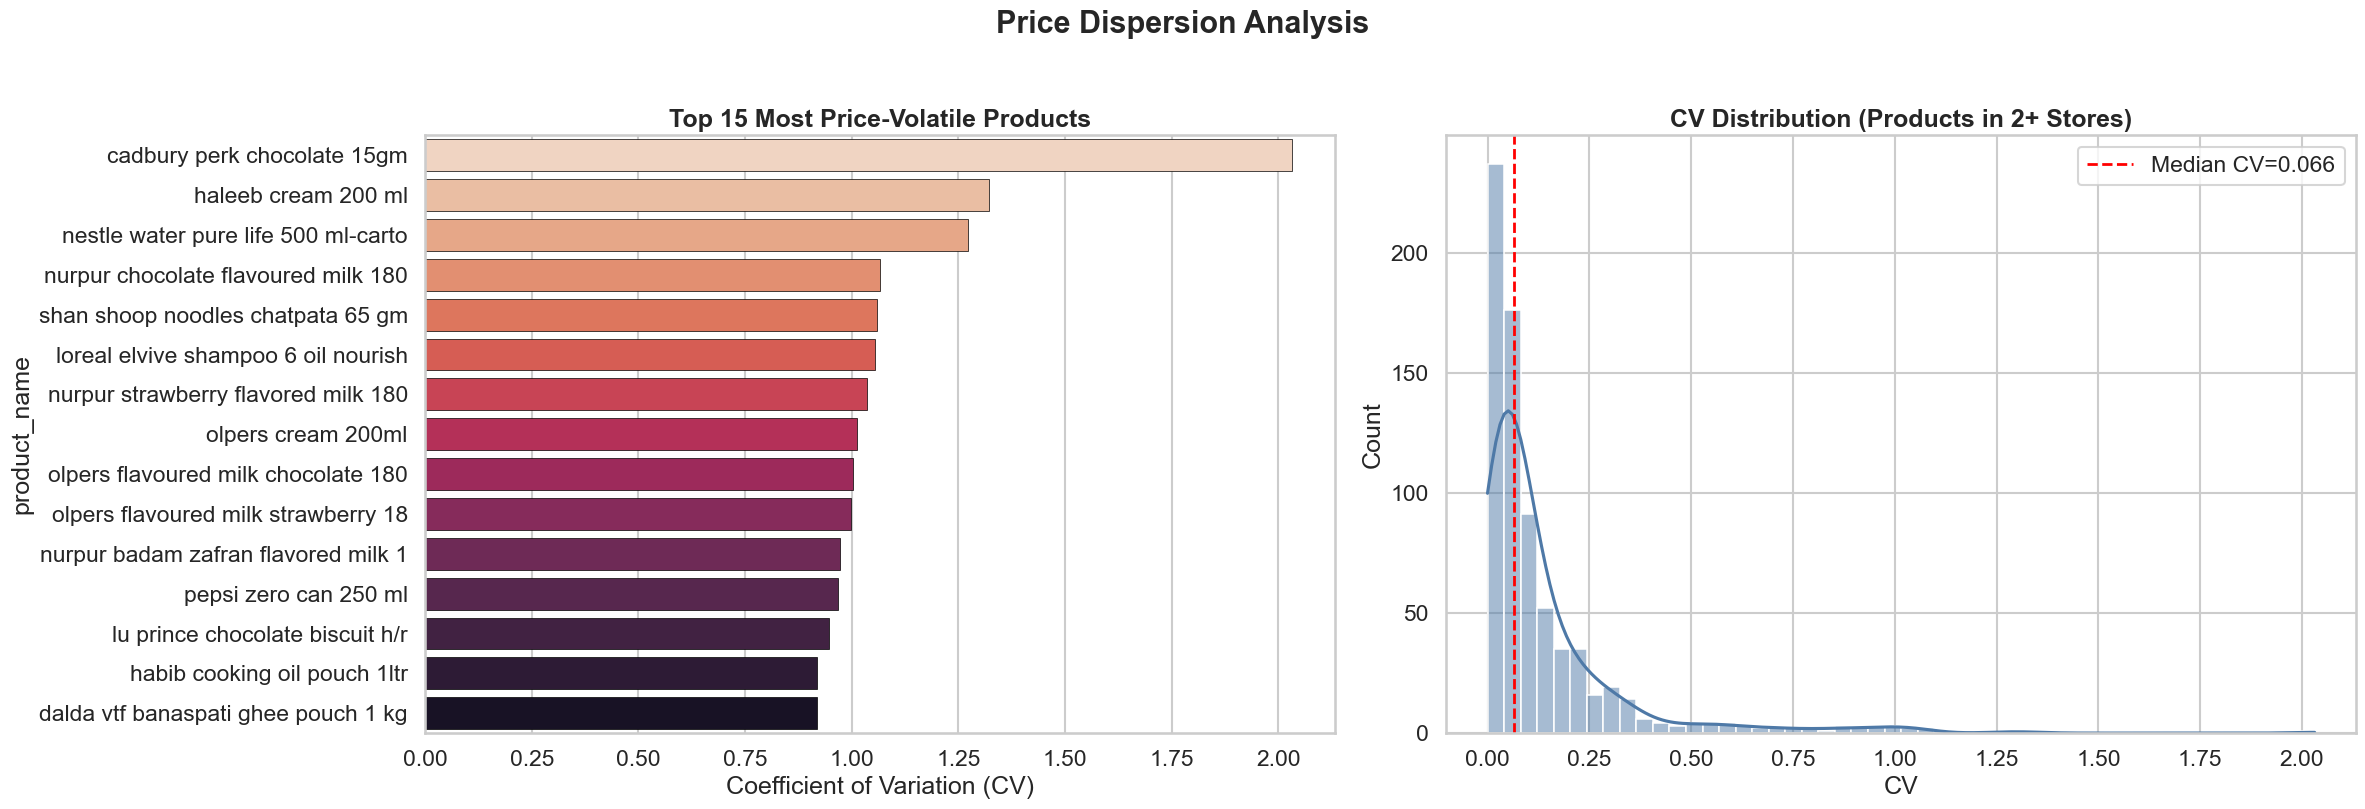

In [3]:
top = product_metrics.nlargest(15, 'cv')

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Top Dispersed
sns.barplot(y=top['product_name'].str[:35], x=top['cv'], ax=axes[0], palette='rocket_r', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 15 Most Price-Volatile Products')
axes[0].set_xlabel('Coefficient of Variation (CV)')

# CV Distribution
multi = product_metrics[product_metrics['num_stores'] >= 2]
sns.histplot(multi['cv'].dropna(), ax=axes[1], bins=50, kde=True, color='#4e79a7', edgecolor='white')
axes[1].axvline(multi['cv'].median(), color='red', ls='--', lw=2, label=f'Median CV={multi["cv"].median():.3f}')
axes[1].set_title('CV Distribution (Products in 2+ Stores)')
axes[1].set_xlabel('CV'); axes[1].legend()

plt.suptitle('Price Dispersion Analysis', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_dispersion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.2 — Store-Level Metrics (Section 3.2)

In [4]:
product_means = df.groupby('product_id')['price_clean'].mean().rename('market_mean')
df2 = df.join(product_means, on='product_id')
df2['relative_index'] = df2['price_clean'] / df2['market_mean']

store_metrics = df2.groupby('store_name').agg(
    avg_relative_index = ('relative_index', 'mean'),
    median_deviation   = ('relative_index', lambda x: (x - 1).median()),
    price_volatility   = ('relative_index', 'std'),
    total_products     = ('product_id', 'nunique'),
).reset_index()

display(store_metrics.style.format({
    'avg_relative_index': '{:.4f}',
    'median_deviation': '{:+.4f}',
    'price_volatility': '{:.4f}',
    'total_products': '{:,}'
}).set_caption('Store-Level Price Index Summary'))

,store_name,avg_relative_index,median_deviation,price_volatility,total_products
0,Al-Fatah,1.0345,+0.0179,0.2251,546
1,Chase Up,0.9840,-0.0040,0.2327,598
2,Metro,0.9623,-0.0503,0.4070,433


## 5.3 — Leader Dominance Index (LDI) — Section 3.3

In [5]:
# Leader Dominance Index (LDI) Calculation
# Formula: LDI = (Count of products where store is cheapest) / (Total matched products)

# Calculate LDI per store
idi_base = df.groupby(['product_id', 'store_name'])['price_clean'].mean().reset_index()
min_prices = idi_base.groupby('product_id')['price_clean'].min().reset_index()
min_prices.columns = ['product_id', 'min_price']

idi_base = idi_base.merge(min_prices, on='product_id')
idi_base['is_cheapest'] = idi_base['price_clean'] <= idi_base['min_price']

ldi_stats = idi_base.groupby('store_name').agg(
    cheapest_count = ('is_cheapest', 'sum'),
    total_products  = ('product_id', 'count')
).reset_index()

ldi_stats['ldi'] = (ldi_stats['cheapest_count'] / ldi_stats['total_products']) * 100

# NEW: Category-wise LDI (Mandatory Sec 3.3)
cat_ldi = idi_base.merge(df[['product_id', 'category_normalized']].drop_duplicates(), on='product_id')
cat_ldi_stats = cat_ldi.groupby(['category_normalized', 'store_name']).agg(
    cheapest_count = ('is_cheapest', 'sum'),
    total_products  = ('product_id', 'count')
).reset_index()
cat_ldi_stats['ldi'] = (cat_ldi_stats['cheapest_count'] / cat_ldi_stats['total_products']) * 100

# NEW: Weighted LDI (Weighted by category size - Mandatory Sec 3.3)
cat_weights = df.groupby('category_normalized')['product_id'].nunique().reset_index()
cat_weights.columns = ['category_normalized', 'cat_size']
cat_weights['weight'] = cat_weights['cat_size'] / cat_weights['cat_size'].sum()

weighted_ldi = cat_ldi_stats.merge(cat_weights, on='category_normalized')
weighted_ldi['weighted_contribution'] = weighted_ldi['ldi'] * weighted_ldi['weight']
final_weighted_ldi = weighted_ldi.groupby('store_name')['weighted_contribution'].sum().reset_index()
final_weighted_ldi.columns = ['store_name', 'weighted_ldi']

print("Global LDI Stats:")
display(ldi_stats)
print("\nWeighted LDI Stats:")
display(final_weighted_ldi)
print("\nCategory-wise LDI (Top 10):")
display(cat_ldi_stats.head(10))

Global LDI Stats:


,store_name,cheapest_count,total_products,ldi
0,Al-Fatah,116,546,21.245421
1,Chase Up,313,598,52.341137
2,Metro,307,433,70.900693



Weighted LDI Stats:


,store_name,weighted_ldi
0,Al-Fatah,20.895168
1,Chase Up,50.807600
2,Metro,67.440740



Category-wise LDI (Top 10):


,category_normalized,store_name,cheapest_count,total_products,ldi
0,Always,Al-Fatah,1,2,50.000000
1,Always,Chase Up,1,2,50.000000
2,Ariel,Al-Fatah,1,3,33.333333
3,Ariel,Chase Up,1,3,33.333333
4,Ariel,Metro,1,1,100.000000
5,Baby,Al-Fatah,0,2,0.000000
6,Baby,Chase Up,0,3,0.000000
7,Baby,Metro,4,4,100.000000
8,Baby Care,Al-Fatah,3,11,27.272727
9,Baby Care,Chase Up,6,10,60.000000


## 5.4 — Store Price Dispersion (Boxenplot)

C:\Users\Nouman\AppData\Local\Temp\ipykernel_1252\778686731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='store_name', y='price_clean', palette=STORE_COLORS, width=0.6)


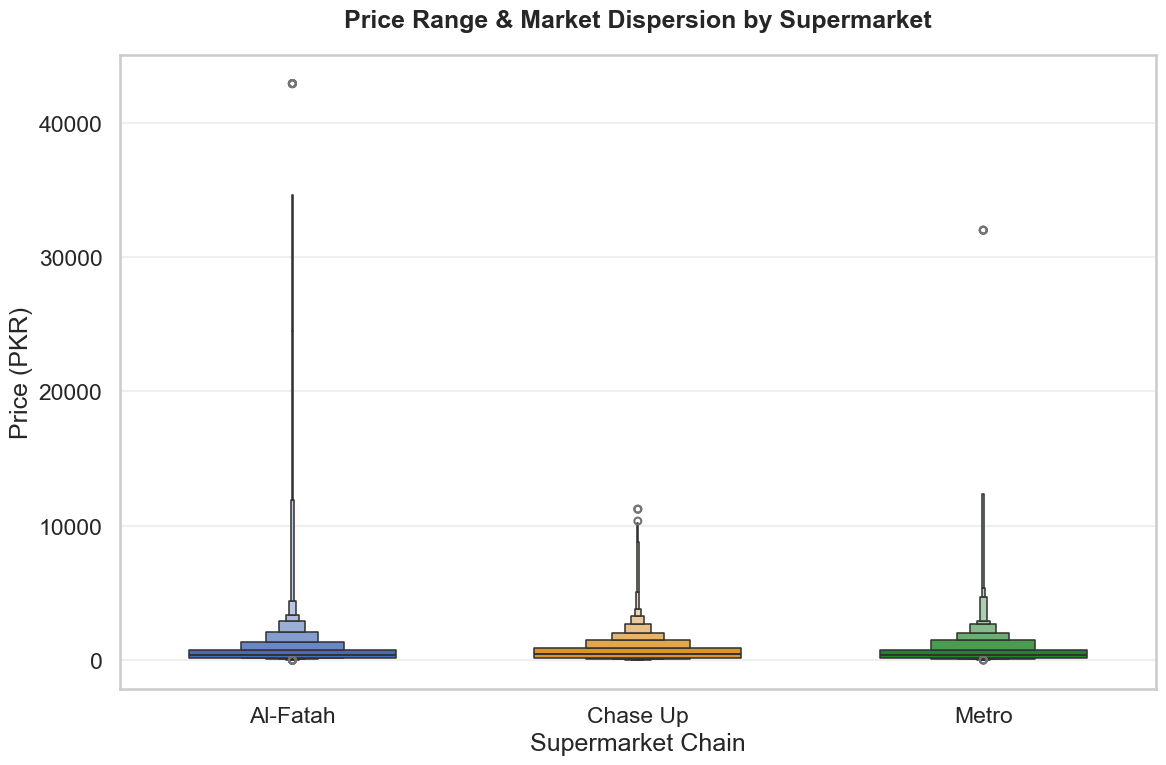

In [6]:
# Professional Boxenplot for Price Dispersion
plt.figure(figsize=(12, 8))
sns.boxenplot(data=df, x='store_name', y='price_clean', palette=STORE_COLORS, width=0.6)
plt.title("Price Range & Market Dispersion by Supermarket", pad=20)
plt.ylabel("Price (PKR)")
plt.xlabel("Supermarket Chain")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_store_boxenplot.png', dpi=300)
plt.show()